# GRU for Time Series Prediction

In [1]:
# Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense  # Note the change to GRU here
from sklearn.preprocessing import MinMaxScaler

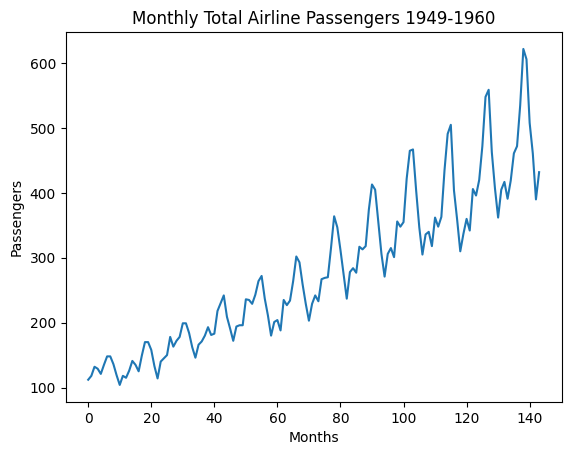

In [2]:
# Load dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
dataframe = pd.read_csv(url, usecols=[1], engine='python')
plt.plot(dataframe)
plt.xlabel("Months")
plt.ylabel("Passengers")
plt.title("Monthly Total Airline Passengers 1949-1960")
plt.show()

In [3]:
# Normalize the dataset
scaler = MinMaxScaler(feature_range=(0, 1))
dataset = scaler.fit_transform(dataframe.values.astype('float32'))

# Split into train and test sets
train_size = int(len(dataset) * 0.67)
test_size = len(dataset) - train_size
train, test = dataset[0:train_size,:], dataset[train_size:len(dataset),:]

## taset Matrix
- This utility function creates a dataset matrix. Given data, and choosing a certain time step, it will create input-output pairs.

In [4]:
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset)-look_back-1):
        a = dataset[i:(i+look_back), 0]
        X.append(a)
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Reshape into X=t and Y=t+1, choosing a timestep of 3
look_back = 3
X_train, y_train = create_dataset(train, look_back)
X_test, y_test = create_dataset(test, look_back)

# Reshape input to be [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

## GRU Model Building & Training

In [5]:
# Create and fit the GRU network
model = Sequential()
model.add(GRU(4, input_shape=(look_back, 1)))  # Change LSTM to GRU here
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')
model.fit(X_train, y_train, epochs=100, batch_size=1, verbose=2)

c:\Users\dell\miniconda3\envs\Deep_Learning\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
92/92 - 3s - 32ms/step - loss: 0.0081
Epoch 2/100
92/92 - 0s - 3ms/step - loss: 0.0050
Epoch 3/100
92/92 - 0s - 2ms/step - loss: 0.0042
Epoch 4/100
92/92 - 0s - 3ms/step - loss: 0.0038
Epoch 5/100
92/92 - 0s - 3ms/step - loss: 0.0034
Epoch 6/100
92/92 - 0s - 3ms/step - loss: 0.0034
Epoch 7/100
92/92 - 0s - 3ms/step - loss: 0.0032
Epoch 8/100
92/92 - 0s - 3ms/step - loss: 0.0033
Epoch 9/100
92/92 - 0s - 3ms/step - loss: 0.0031
Epoch 10/100
92/92 - 0s - 3ms/step - loss: 0.0031
Epoch 11/100
92/92 - 0s - 4ms/step - loss: 0.0032
Epoch 12/100
92/92 - 0s - 3ms/step - loss: 0.0031
Epoch 13/100
92/92 - 0s - 3ms/step - loss: 0.0030
Epoch 14/100
92/92 - 0s - 2ms/step - loss: 0.0031
Epoch 15/100
92/92 - 0s - 3ms/step - loss: 0.0030
Epoch 16/100
92/92 - 0s - 3ms/step - loss: 0.0030
Epoch 17/100
92/92 - 0s - 2ms/step - loss: 0.0030
Epoch 18/100
92/92 - 0s - 2ms/step - loss: 0.0030
Epoch 19/100
92/92 - 0s - 2ms/step - loss: 0.0030
Epoch 20/100
92/92 - 0s - 3ms/step - loss: 0.0028
Epoch 21

In [6]:
# Make predictions
trainPredict = model.predict(X_train)
testPredict = model.predict(X_test)

# Invert predictions
trainPredict = scaler.inverse_transform(trainPredict)
y_train = scaler.inverse_transform([y_train])
testPredict = scaler.inverse_transform(testPredict)
y_test = scaler.inverse_transform([y_test])

# Calculate root mean squared error
trainScore = np.sqrt(((trainPredict-y_train)**2).mean())
testScore = np.sqrt(((testPredict-y_test)**2).mean())
print('Train Score: %.2f RMSE' % (trainScore))
print('Test Score: %.2f RMSE' % (testScore))

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 178ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Train Score: 97.28 RMSE
Test Score: 103.11 RMSE


## Visualizing Predictions

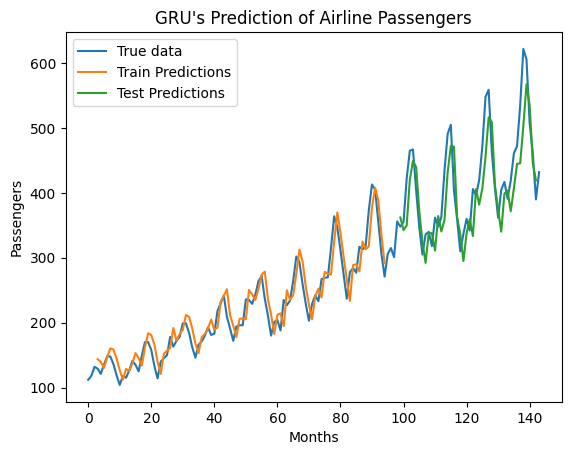

In [7]:
# Shift train predictions for plotting
trainPredictPlot = np.empty_like(dataset)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[look_back:len(trainPredict)+look_back, :] = trainPredict

# Shift test predictions for plotting
testPredictPlot = np.empty_like(dataset)
testPredictPlot[:, :] = np.nan
testPredictPlot[len(trainPredict)+(look_back*2)+1:len(dataset)-1, :] = testPredict

# Plot baseline and predictions
plt.plot(scaler.inverse_transform(dataset), label="True data")
plt.plot(trainPredictPlot, label="Train Predictions")
plt.plot(testPredictPlot, label="Test Predictions")
plt.xlabel("Months")
plt.ylabel("Passengers")
plt.title("GRU's Prediction of Airline Passengers")
plt.legend()
plt.show()

# About the Author

<div style="background-color: #f8f9fa; border-left: 5px solid #28a745; padding: 20px; margin-bottom: 20px; border-radius: 5px;">
  <h2 style="color: #28a745; margin-top: 0; font-family: 'Poppins', sans-serif;">Muhammad Atif Latif</h2>
  <p style="font-size: 16px; color: #495057;">Data Scientist & Machine Learning Engineer</p>
  
  <p style="font-size: 15px; color: #6c757d; margin-top: 15px;">
    Passionate about building AI solutions that solve real-world problems. Specialized in machine learning, 
    deep learning, and data analytics with experience implementing production-ready models.
  </p>
</div>

## Connect With Me

<div style="display: flex; flex-wrap: wrap; gap: 10px; margin-top: 15px;">
  <a href="https://github.com/m-Atif-Latif" target="_blank">
    <img src="https://img.shields.io/badge/GitHub-Follow-212121?style=for-the-badge&logo=github" alt="GitHub">
  </a>
  <a href="https://www.kaggle.com/matiflatif" target="_blank">
    <img src="https://img.shields.io/badge/Kaggle-Profile-20BEFF?style=for-the-badge&logo=kaggle" alt="Kaggle">
  </a>
  <a href="https://www.linkedin.com/in/muhammad-atif-latif-13a171318" target="_blank">
    <img src="https://img.shields.io/badge/LinkedIn-Connect-0077B5?style=for-the-badge&logo=linkedin" alt="LinkedIn">
  </a>
  <a href="https://x.com/mianatif5867" target="_blank">
    <img src="https://img.shields.io/badge/Twitter-Follow-1DA1F2?style=for-the-badge&logo=twitter" alt="Twitter">
  </a>
  <a href="https://www.instagram.com/its_atif_ai/" target="_blank">
    <img src="https://img.shields.io/badge/Instagram-Follow-E4405F?style=for-the-badge&logo=instagram" alt="Instagram">
  </a>
  <a href="mailto:muhammadatiflatif67@gmail.com">
    <img src="https://img.shields.io/badge/Email-Contact-D14836?style=for-the-badge&logo=gmail" alt="Email">
  </a>
</div>

---